In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split   
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [4]:
df = pd.read_csv('../data/gym_churn_us.csv')

In [ ]:
caida_frecuencia = df['Avg_class_frequency_total'] - df['Avg_class_frequency_current_month']
df['caida_frecuencia'] = caida_frecuencia

In [8]:
df.isnull().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
caida_frecuencia                     0
dtype: int64

array([[<Axes: title={'center': 'gender'}>,
        <Axes: title={'center': 'Near_Location'}>,
        <Axes: title={'center': 'Partner'}>,
        <Axes: title={'center': 'Promo_friends'}>],
       [<Axes: title={'center': 'Phone'}>,
        <Axes: title={'center': 'Contract_period'}>,
        <Axes: title={'center': 'Group_visits'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Avg_additional_charges_total'}>,
        <Axes: title={'center': 'Month_to_end_contract'}>,
        <Axes: title={'center': 'Lifetime'}>,
        <Axes: title={'center': 'Avg_class_frequency_total'}>],
       [<Axes: title={'center': 'Avg_class_frequency_current_month'}>,
        <Axes: title={'center': 'Churn'}>,
        <Axes: title={'center': 'caida_frecuencia'}>, <Axes: >]],
      dtype=object)

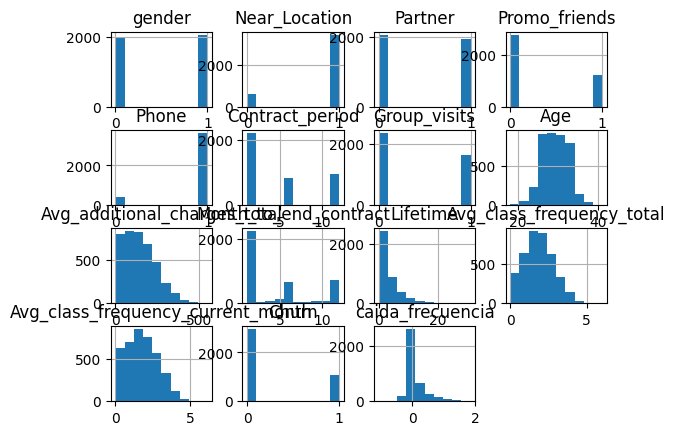

In [9]:
df.hist()

Para normalizar los datos dependiendo de la distribución de cada uno de estos:

In [16]:
columnas_campana = ['Age', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month', 'caida_frecuencia']
columnas_sesgadas_o_fijas = ['Lifetime', 'Avg_additional_charges_total', 'Contract_period', 'Month_to_end_contract']

In [ ]:
preprocesador = ColumnTransformer(
    transformers=[
        ('estandarizacion', StandardScaler(), columnas_campana),
        ('normalizacion', MinMaxScaler(), columnas_sesgadas_o_fijas)
    ],
    remainder='passthrough' 
)

In [20]:
X = df.drop(columns=['Churn', 'Avg_class_frequency_total', 'Phone', 'gender'])
y = df['Churn']

In [21]:
y.value_counts()

Churn
0    2939
1    1061
Name: count, dtype: int64

In [22]:
ros = RandomOverSampler()
X_ros, y_ros = ros.fit_resample(X, y)

rus = RandomUnderSampler()
X_rus, y_rus = rus.fit_resample(X, y)

smote = SMOTE()
X_smote, y_smote = smote.fit_resample(X, y)

NameError: name 'RandomOverSampler' is not defined